# Chapter 23: System Dynamics with DisSModel

*Part IV — DisSModel: Core and Paradigms*

Implemented by the [`dissmodel-sysdyn`](https://github.com/DisSModel/dissmodel-sysdyn) package.

> **Live demo:** every model in this chapter is also runnable directly in the browser, no installation required — [dissmodel-sysdyn-demo on Hugging Face Spaces](https://huggingface.co/spaces/profsergiocosta/dissmodel-sysdyn-demo).

## Learning Objectives

By the end of this chapter you will be able to:

- Install and explore the `dissmodel-sysdyn` model library
- Understand stocks, flows, and feedback loops
- Recognize the categories of available system dynamics models
- Compare a TerraME Lua model against its DisSModel equivalent, term for term

In [1]:
# Standard imports — add chapter-specific imports below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Every model in Chapters 21 and 22 kept its state in a `gdf` or a `backend` — geometry mattered. System dynamics models don't have geometry at all: a population, a temperature, a susceptible/infected/recovered split are just numbers, changing over time according to equations, with no coordinate attached to any of them. `dissmodel-sysdyn`'s models subclass `dissmodel.core.Model` directly — no `SpatialModel`, no `RasterModel` — proof that the lifecycle Chapter 22 introduced (`setup → execute`, driven by `Environment.run()`) was never really about space in the first place.

## The dissmodel-sysdyn Package

`dissmodel-sysdyn` isn't on PyPI yet, so it installs the same way every other extension package has since Chapter 22:

```bash
pip install "git+https://github.com/DisSModel/dissmodel-sysdyn.git"
```

Fourteen models live in `src/dissmodel_sysdyn/models/`, and — unlike some of this book's earlier real-data detours — this isn't a partial port: every one of TerraME's `sysdyn` models has a DisSModel counterpart, file for file:

| `dissmodel_sysdyn.models` | TerraME `sysdyn` (`lua/`) | What it models |
|---|---|---|
| `tub.Tub` | `Tub.lua` | Water-in-tub stock-and-flow |
| `cofee.Coffee` | `Coffee.lua` | Newton's law of cooling |
| `sir.SIR` | `SIR.lua` | Deterministic SIR epidemiology |
| `chaotic_growth.ChaoticGrowth` | `ChaoticGrowth.lua` | Logistic-map chaos |
| `lorenz.Lorenz` | `Lorenz.lua` | Lorenz attractor |
| `predatorprey.PredatorPrey` | `PredatorPrey.lua` | Lotka-Volterra predator-prey |
| `daisyworld.Daisyworld` | `Daisyworld.lua` | Daisyworld / Gaia hypothesis |
| `limited_growth.LimitedGrowth` | `LimitedGrowth.lua` | Logistic growth with carrying capacity |
| `homeostasis.Homeostasis` | `Homeostasis.lua` | Fixed inflow, proportional outflow |
| `population_growth.PopulationGrowth` | `PopulationGrowth.lua` | Exponential growth, variable rate |
| `yeast.Yeast` | `Yeast.lua` | Yeast population growth |
| `random_walk.RandomWalk` | `RandomWalk.lua` | Simple random walk |
| `mono_lake.MonoLake` | `MonoLake.lua` | Mono Lake water balance |
| `room_temperature.RoomTemperature` | `RoomTemperature.lua` | Thermostat with varying climate |

Every one of them is runnable the same two ways Chapter 22 introduced for `dissmodel-ca`, plus this package's own optional Streamlit app:

```bash
python examples/cli/sysdyn_sir.py
jupyter notebook examples/notebooks/
streamlit run examples/streamlit/sysdyn_all.py
```

This chapter works through six of the fourteen in real depth — `Tub`, `Coffee`, and `SIR` below, then `Lorenz`/`ChaoticGrowth`, `PredatorPrey`, and `Daisyworld` further down — chosen to cover a genuinely different modeling idea each (stock-and-flow, feedback, compartments, chaos, coupled populations, a planetary feedback loop), not because the other eight are less real. Every one of the fourteen follows the identical `setup()`/`execute()` shape these six demonstrate; the package's own notebooks in `examples/notebooks/` are the place to see the rest.

## Theory: Stocks and Flows

Modeling a system means deciding which measurable parts of reality it has, and how they affect each other. System Dynamics (Meadows, 2008) reduces every such part to one of two kinds of element:

- **Stock** — a measurable quantity that has accumulated by a given moment: water in a tub, a population count, a temperature.
- **Flow** — the *rate of change* of a stock: what comes in (inflow), what goes out (outflow).

$$\text{stock}(t) = \text{stock}(t - dt) + \text{inflow} \cdot dt - \text{outflow} \cdot dt$$

Three consequences follow directly, and they shape every model in this chapter:

1. There are exactly two ways to increase a stock — raise the inflow, or lower the outflow.
2. Stocks act as delays or buffers: they don't react instantaneously to a flow change, which is what gives a system *inertia*.
3. Stocks decouple inflow from outflow — a tub can be filling and draining at the same moment; the stock only ever records the net balance of two independent forces.

### Tub: TerraME vs DisSModel

TerraME's `Tub.lua` needed an explicit `Timer`, with the periodic inflow modeled as a second, separately-scheduled `Event`. `dissmodel_sysdyn.models.tub.Tub` reaches the identical behavior with no `Timer` at all — `Environment` already calls `execute()` every tick, so the periodic inflow becomes nothing more than a step counter checked with `%`:

**Definition** — TerraME's `Tub.lua` on the left; the state, the rule, and the periodic inflow all carry over line for line, only the `Timer`/`Event` scaffolding disappears:

```lua
-- Tub.lua (TerraME)
Tub = Model{
	water = 40,
	outFlow = 5,
	inFlow = 0,
	finalTime = 8,
	execute = function(model)
		model.water = model.water - model.outFlow
		if model.water < 0 then
			model.water = 0
		end
	end,
	-- ...init() wires a Chart and a Timer with two Events: the outflow
	-- above every tick, and a second Event{start=10, period=10, ...}
	-- that adds inFlow every ten ticks -- see "Execution" below
}
```

The DisSModel translation, defined here and actually run in this kernel — not just described — so its behavior below is real, not asserted:

In [ ]:
from dissmodel.core import Model
from dissmodel.visualization import track_plot

@track_plot("Water", "blue")
class Tub(Model):
    def setup(self, water=40.0, out_flow=5.0, in_flow=0.0, in_period=10):
        self.water     = water
        self.out_flow  = out_flow
        self.in_flow   = in_flow
        self.in_period = in_period
        self._step     = 0

    def execute(self):
        self._step += 1
        self.water -= self.out_flow
        if self.water < 0.0:
            self.water = 0.0
        if self._step % self.in_period == 0:
            self.water += self.in_flow


**Execution** — TerraME needs its own `Environment`/`run()` pair too, in a separate scenario script, not inside `Tub.lua` itself:

```lua
-- tub-scenarios.lua (TerraME)
import("sysdyn")

env = Environment{
	scenario1 = Tub{},
	scenario2 = Tub{inFlow = 40, finalTime = 50}
}

env:run()
```

The DisSModel equivalent is the code cell right below — construct an `Environment`, construct the model, call `run()`. The two are close enough that the main thing to notice is what's *missing*: no `import("sysdyn")` step, and no separate scenario file — `Environment` and `Tub` are just Python objects, importable and runnable from the same script or notebook cell.

In [3]:
from dissmodel.core import Environment
from dissmodel_sysdyn.models import Tub

env = Environment(start_time=0, end_time=20)
tub = Tub(water=40.0, out_flow=5.0, in_flow=30.0, in_period=10)
env.run()
print("Water remaining after 20 ticks:", tub.water)

Running from 0 to 20 (duration: 20)
Water remaining after 20 ticks: 10.0


DisSModel's implicit `setup()` → `execute()` cycle is what absorbs TerraME's `Timer`/`Event` scaffolding — the same simplification Chapter 22's `Ticker` example demonstrated on a toy, now paying off on a real stock-and-flow model.


## Feedbacks: Balancing and Reinforcing

A feedback is how a system affects itself — part of an outflow loops back to influence an inflow, closing a causal loop. Because the effect always takes one `dt` to propagate, a feedback can only shape the *next* step, never the current one.

**Balancing** (negative, self-correcting) feedback is goal-seeking: the system moves toward a reference value and settles there. Coffee cooling toward room temperature is the canonical example — the rate of heat loss is proportional to how far the coffee still is from equilibrium, so it converges whether it starts hotter or colder than the room.

**Reinforcing** (positive, self-amplifying) feedback has no such ceiling built into the equation itself — it amplifies deviations rather than correcting them, exactly how unconstrained population growth behaves. Every reinforcing feedback in the real world eventually meets a limit from somewhere else — resources, space, or a balancing feedback stepping in — nothing grows exponentially forever.

### Coffee: TerraME vs DisSModel

Newton's law of cooling, reproduced term for term — only the Lua constant `0.1` becomes a named, Streamlit-exposable `cooling_rate` parameter:

**Definition** — Newton's law of cooling, reproduced term for term; only the Lua constant `0.1` becomes a named, Streamlit-exposable `cooling_rate`:

```lua
-- Coffee.lua (TerraME)
Coffee = Model{
	temperature     = 80,
	roomTemperature = 20,
	finalTime       = 20,
	execute = function(model)
		local difference = model.temperature - model.roomTemperature
		model.temperature =  model.temperature - difference * 0.1
	end,
	-- ...init() wires a Chart and a Timer -- see "Execution" below
}
```

And the real, installed `Coffee.setup()`/`execute()` from `dissmodel-sysdyn`:

```python
# cofee.py (dissmodel-sysdyn)
def setup(
    self,
    temperature: float = 80.0,
    room_temperature: float = 20.0,
    cooling_rate: float = 0.1,
) -> None:
    self.temperature = temperature
    self.room_temperature = room_temperature
    self.cooling_rate = cooling_rate

def execute(self) -> None:
    self.temperature -= self.cooling_rate * (self.temperature - self.room_temperature)
```

**Execution** — three starting temperatures, one `Chart` shared across all three, in TerraME's own scenario style:

```lua
-- coffee-scenarios.lua (TerraME)
import("sysdyn")

env = Environment{
	Coffee{},
	Coffee{temperature = 20},
	Coffee{temperature = 5}
}

chart = Chart{target = env, select = "temperature"}
env:add(Event{action = chart})
env:run()
```

Same shape as `Tub` above — `Environment{...}` then `env:run()` — and the same shape the code cell below builds in Python, minus the separate scenario file.

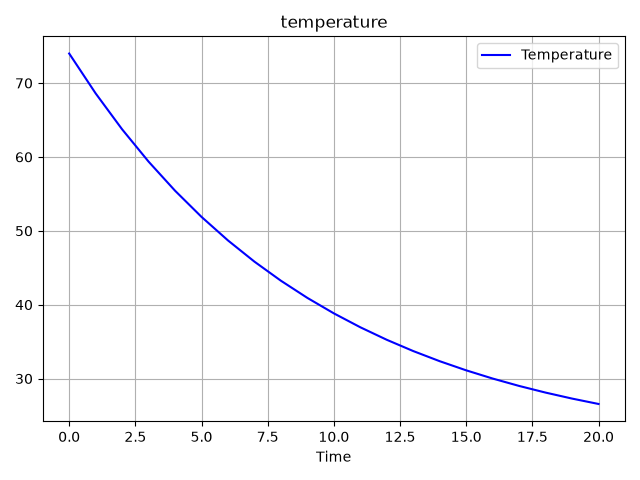

Coffee temperature after 20 ticks: 26.6°C


In [10]:
from dissmodel_sysdyn.models import Coffee
from dissmodel.visualization import Chart

env = Environment(start_time=0, end_time=20)
coffee = Coffee(temperature=80.0, room_temperature=20.0, cooling_rate=0.1)
Chart(show_legend=True, show_grid=True, title="temperature")
env.run()
print(f"Coffee temperature after 20 ticks: {coffee.temperature:.1f}°C")

## Epidemiology: The SIR Model

`SIR` splits a population into three stocks that transform into one another: **S**usceptible → **I**nfected → **R**ecovered. The transition rate depends on how long an infection lasts, how many contacts an infected individual has per tick, and what fraction of those contacts are with someone still susceptible:

**Definition** — the compartment transitions match term for term; the educational-campaign feedback (the `Event` that halves `contacts` once `infected` crosses `maximum`) has no counterpart below — the gap the warning further down discusses:

```lua
-- SIR.lua (TerraME)
SIR = Model{
	susceptible = 9998, infected = 2, recovered = 0,
	duration = 2, finalTime = 30, contacts = 6,
	maximum = math.huge, probability = 0.25,
	init = function(model)
		-- ...Chart wired to susceptible/infected/recovered...
		model.timer = Timer{
			Event{action = function()
				local proportion = model.susceptible /
					(model.susceptible + model.infected + model.recovered)
				local newInfected = model.infected * model.contacts * model.probability * proportion
				local newRecovered = model.infected / model.duration

				model.susceptible = model.susceptible - newInfected
				model.recovered = model.recovered + newRecovered
				model.infected = model.infected + newInfected - newRecovered
			end},
			Event{action = function()  -- the gap: not carried over to Python
				if model.infected >= model.maximum then
					model.contacts = model.contacts / 2
					return false
				end
			end},
			Event{action = model.chart}
		}
	end
}
```

The DisSModel translation, defined here and actually run in this kernel — not just described — so its behavior below is real, not asserted:

In [6]:
from dissmodel.core import Model
from dissmodel.visualization import track_plot

@track_plot("Susceptible", "green")
@track_plot("Infected", "red")
@track_plot("Recovered", "blue")
class SIR(Model):
    def setup(self, susceptible=9998, infected=2, recovered=0,
              duration=2, contacts=6, probability=0.25):
        self.susceptible = susceptible
        self.infected    = infected
        self.recovered   = recovered
        self.duration    = duration
        self.contacts    = contacts
        self.probability = probability

    def execute(self):
        total = self.susceptible + self.infected + self.recovered
        alpha = self.contacts * self.probability

        new_infected  = self.infected * alpha * (self.susceptible / total)
        new_recovered = self.infected / self.duration

        self.susceptible -= new_infected
        self.infected    += new_infected - new_recovered
        self.recovered   += new_recovered


**Execution** — three scenarios sharing one `Chart`, the same shape the code cell below builds with `Environment` + `SIR()` + `env.run()`:

```lua
-- infection-scenarios-1.lua (TerraME)
import("sysdyn")

env = Environment{
	SIR{},
	SIR{duration = 4},
	SIR{duration = 8}
}

chart = Chart{target = env, select = "infected"}
env:add(Timer{Event{action = chart}})
env:run()
```

In [7]:
from dissmodel_sysdyn.models import SIR

env = Environment(start_time=0, end_time=20)
sir = SIR(susceptible=9998, infected=2, recovered=0, duration=2, contacts=6, probability=0.25)
env.run()
print(f"S={sir.susceptible:.0f}  I={sir.infected:.0f}  R={sir.recovered:.0f}")

Running from 0 to 20 (duration: 20)
S=252  I=43  R=9705


Every model in `dissmodel-sysdyn` is already decorated with `@track_plot` per stock — `SIR` tracks `Susceptible`, `Infected`, and `Recovered` this way — which is what lets a `Chart` component render them live with no extra wiring on your part. Attach one the same way `Map` attached itself to a grid in Chapter 21: construct it, then `env.run()`:

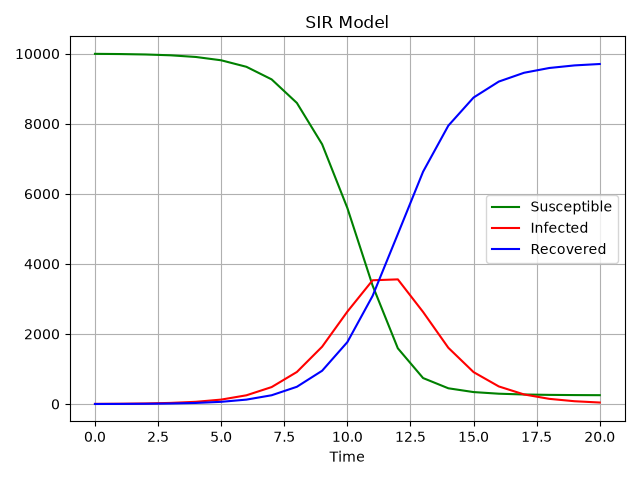

In [8]:
from dissmodel.visualization import Chart

env = Environment(start_time=0, end_time=20)
sir = SIR(susceptible=9998, infected=2, recovered=0, duration=2, contacts=6, probability=0.25)
Chart(show_legend=True, show_grid=True, title="SIR Model")

env.run()

`Chart` needed no reference to `sir` at all — it discovers every `@track_plot`-decorated attribute from whatever models are registered in the active `Environment` and plots all of them automatically, live, one frame per tick. That's the same automatic-discovery spirit `dissmodel-ca`'s Streamlit explorer (Chapter 24) uses to turn every `CellularAutomaton` subclass into a UI control without listing them by hand.

<div class="admonition warning">
<p class="admonition-title">Watch out</p>
<p>The original TerraME <code>SIR.lua</code> had a second behavior not carried over into <code>dissmodel-sysdyn</code>'s <code>sir.py</code>: an educational campaign that cuts <code>contacts</code> in half once infections cross a threshold. If your own model needs that branch, it has to be added to <code>execute()</code> by hand — it is a known, documented gap, not an oversight to work around silently.</p>
</div>

## Chaos and Sensitivity to Initial Conditions

Edward Lorenz discovered deterministic chaos essentially by accident, rounding a printed initial condition from six decimal places to three and finding the re-run weather simulation diverged completely from the original within a handful of steps — two systems, both simple enough to fit on one screen, reproduce that same sensitivity. `dissmodel_sysdyn.models.chaotic_growth.ChaoticGrowth` (the logistic map, `rate=4.0`) and `dissmodel_sysdyn.models.lorenz.Lorenz` (`rho=28.0`, `sigma=10.0`, `beta=8/3` — the exact constants Lorenz's own 1963 paper used) are both direct ports of `ChaoticGrowth.lua` and `Lorenz.lua`, parameter-for-parameter. See the package table above, and `dissmodel-sysdyn`'s own `examples/notebooks/sysdyn_chaotic_growth.ipynb` and `sysdyn_lorenz.ipynb` for the full walkthrough this chapter doesn't have room for.

## Predator-Prey and Phase-Plane Analysis

The Lotka-Volterra model formalizes two rules — prey mostly die by predation, and predator survival depends on prey availability — plus one mathematical assumption: the two species meet at a rate proportional to *both* populations at once:

$$\frac{dx}{dt} = rx - axy \qquad \frac{dy}{dt} = eaxy - my$$

**Definition** — Lotka-Volterra, term for term; TerraME exposes every parameter as a `Choice` (a bounded range, for its GUI slider), which DisSModel simply drops to a plain keyword default:

```lua
-- PredatorPrey.lua (TerraME)
PredatorPrey = Model{
	predator        = Choice{min = 1, default = 40},
	prey            = Choice{min = 1, default = 1000},
	preyGrowth      = Choice{min = 0.000001, max = 1,   default = 0.08},
	preyDeathPred   = Choice{min = 0.000001, max = 0.5, default = 0.001},
	predDeath       = Choice{min = 0.000001, max = 0.5, default = 0.02},
	predGrowthKills = Choice{min = 0,        max = 0.5, default = 0.00002},
	execute = function(model)
		model.prey = model.prey + model.preyGrowth * model.prey
		                - model.preyDeathPred * model.prey * model.predator
		model.predator = model.predator - model.predDeath * model.predator
		              + model.predGrowthKills * model.prey * model.predator
	end,
	-- ...init() wires two Charts -- see "Execution" below
}
```

And the real, installed `PredatorPrey.setup()`/`execute()` from `dissmodel-sysdyn`:

```python
# predatorprey.py (dissmodel-sysdyn)
def setup(
    self,
    predator: float = 40.0,
    prey: float = 1000.0,
    prey_growth: float = 0.08,
    prey_death_pred: float = 0.001,
    pred_death: float = 0.02,
    pred_growth_kills: float = 0.00002,
) -> None:
    self.predator       = predator
    self.prey           = prey
    self.prey_growth    = prey_growth
    self.prey_death_pred = prey_death_pred
    self.pred_death     = pred_death
    self.pred_growth_kills = pred_growth_kills

def execute(self) -> None:
    self.prey += (
        self.prey_growth * self.prey
        - self.prey_death_pred * self.prey * self.predator
    )
    self.predator += (
        -self.pred_death * self.predator
        + self.pred_growth_kills * self.prey * self.predator
    )
```

**Execution** — same shape again:

```lua
-- PredatorPrey.lua (TerraME), instantiated directly -- no dedicated scenario file
import("sysdyn")

env = Environment{PredatorPrey{}}
env:run()
```

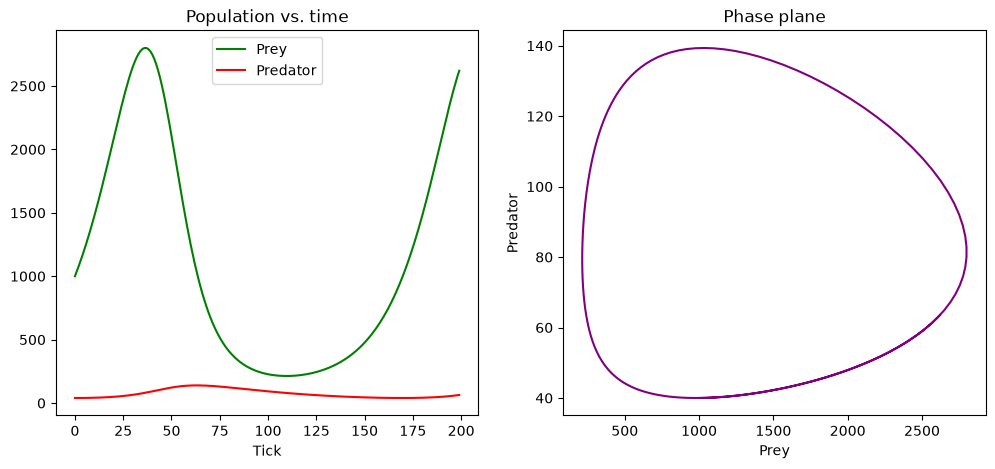

In [9]:
from dissmodel_sysdyn.models import PredatorPrey

env = Environment(start_time=0, end_time=200)
pp = PredatorPrey(
    predator=40.0, prey=1000.0,
    prey_growth=0.08, prey_death_pred=0.001,
    pred_death=0.02, pred_growth_kills=0.00002,
)
prey_history, predator_history = [], []
for _ in range(200):
    prey_history.append(pp.prey)
    predator_history.append(pp.predator)
    pp.execute()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(prey_history, label="Prey", color="green")
axes[0].plot(predator_history, label="Predator", color="red")
axes[0].set_xlabel("Tick")
axes[0].legend()
axes[0].set_title("Population vs. time")

axes[1].plot(prey_history, predator_history, color="purple")
axes[1].set_xlabel("Prey")
axes[1].set_ylabel("Predator")
axes[1].set_title("Phase plane")
plt.show()

Besides the usual population-vs-time chart, this system has a second, more revealing view: the **phase plane** — one population plotted against the other, time itself invisible. In Lotka-Volterra the resulting trajectory is a closed loop, and the point sitting inside every loop is the **equilibrium** — the one stationary state where neither population changes. Setting both rates to zero gives prey = `pred_death / pred_growth_kills` = 1000 and predator = `prey_growth / prey_death_pred` = 80 for these classic parameters (the run above starts at 40 predators, off the equilibrium, which is why it cycles). The loop stays closed in this discrete version too because `execute()` updates prey first and predators from the *new* prey value — a semi-implicit step that preserves orbits, where a plain explicit Euler step would slowly spiral outward. `@track_plot`, the decorator every model in this package uses to feed its own live Streamlit chart, only produces time-series views; a phase-plane plot like the one above has to be assembled by hand from tracked history, exactly as the cell above does by calling `execute()` directly rather than through `env.run()`.

## Daisyworld and the Gaia Hypothesis

James Lovelock, analyzing the Mars Viking mission data, proposed that a planet's biosphere can regulate its own climate without any conscious coordination — Daisyworld is the minimal model that makes the idea concrete: two daisy colors with different albedos compete for space, each preferring a different local temperature, and together they hold the planet's average temperature far more stable than luminosity alone would predict. `dissmodel_sysdyn.models.daisyworld.Daisyworld` is a direct, parameter-for-parameter port of TerraME's `Daisyworld.lua` — same helper calculations (`_planet_temp`, `_local_temp`, `_daisy_growth_rate` in Python; `calcTemp`, `tempNearDaisy`, `daisyGrowthRate` in Lua), same defaults. See the package table above, and `dissmodel-sysdyn`'s own `examples/notebooks/sysdyn_daisyworld.ipynb` for the full walkthrough this chapter doesn't have room for.

## Exercises

1. **Why no substrate?** Open the source for `SIR` (or any model in this chapter) and confirm it extends `dissmodel.core.Model` directly, not `SpatialModel`. In your own words, explain why a system-dynamics model has no use for a `gdf`, a `backend`, or a neighborhood.
2. **Which compartment peaks first?** Run the SIR example with a much shorter `duration` (try `duration=1`) and a longer one (`duration=5`), holding everything else fixed. Which parameter controls how quickly `infected` peaks, and why?
3. **Two kinds of `execute()`.** Compare `SIR.execute()` (three coupled stocks, each a running total) to `Lorenz.execute()` (three coupled rates of change). Both override `execute()` on a plain `Model` and use neither `pre_execute()` nor `post_execute()` — why not?
4. **A feedback of your own.** Sketch, in a sentence, a real-world system with a *reinforcing* feedback you've personally observed (not one already covered in this chapter), and identify what eventually limits it in practice.

In [9]:
# Your code here

## Summary

### Key concepts introduced

- Stocks and flows: a stock accumulates, a flow is its rate of change, and every model in this chapter is built from that one relationship
- Balancing (self-correcting) versus reinforcing (self-amplifying) feedback, and why every reinforcing feedback meets a limit somewhere in the real world
- `dissmodel-sysdyn` models subclass `Model` directly — proof the Chapter 22 lifecycle was never inherently spatial
- `dissmodel-sysdyn`'s full fourteen-model library, mapped file for file against TerraME's own `sysdyn` package — a complete, verified 1:1 port, not a partial one
- `Tub` and `SIR` in full depth — defined as real, running classes in this notebook, not just described, then executed against the maintained package; `Coffee` and `PredatorPrey` as shorter Lua/Python comparisons with no live execution; `ChaoticGrowth`, `Lorenz`, and `Daisyworld` covered at the level of the package table above, each with its own dedicated notebook in `examples/notebooks/`
- The phase plane as a second way to visualize a coupled system, orthogonal to the time-series view `@track_plot` produces automatically
- A documented gap (SIR's educational-campaign branch) as an example of honest scope-limiting rather than silent omission

Chapter 24 returns to spatial models properly, going well beyond Chapter 22's Game of Life teaser into the full `dissmodel-ca` library.

## Further Reading

- Meadows, D. H. (2008). *Thinking in Systems: A Primer*. Chelsea Green Publishing — the standard reference for stock-and-flow thinking
- Lorenz, E. N. (1963). "Deterministic Nonperiodic Flow." *Journal of the Atmospheric Sciences*, 20(2), 130-141 — the original chaos paper
- Watson, A. J., & Lovelock, J. E. (1983). "Biological homeostasis of the global environment: the parable of Daisyworld." *Tellus B*, 35(4), 284-289
- dissmodel-sysdyn on GitHub: <https://github.com/DisSModel/dissmodel-sysdyn>
- TerraME/sysdyn on GitHub — source for every Lua model compared in this chapter (`Tub.lua`, `Coffee.lua`, `SIR.lua`, `ChaoticGrowth.lua`, `Lorenz.lua`, `PredatorPrey.lua`, `Daisyworld.lua`): <https://github.com/TerraME/sysdyn>
- Live demo (no installation required): <https://huggingface.co/spaces/profsergiocosta/dissmodel-sysdyn-demo>